In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import math

h = 6.64*10**(-34)
m = 9.109383701528*10**(-31)
e = 1.602176634*10**(-19)
u = np.array([5000, 4500, 4000, 3500, 3000, 2500])
l = lambda u : h/(np.sqrt(2*m*e*u))
print(l(u))

p = lambda u : np.sqrt(2*m*e*u)
print(p(u))
p_u = p(u)
log_p = np.log(p_u)
print(log_p)

[1.73807449e-11 1.83209137e-11 1.94322635e-11 2.07739635e-11
 2.24384451e-11 2.45800851e-11]
[3.82031958e-23 3.62427338e-23 3.41699771e-23 3.19630868e-23
 2.95920682e-23 2.70137388e-23]
[-51.61912306 -51.67180332 -51.73069483 -51.79746053 -51.87453587
 -51.96569665]


In [2]:
l = 130
d1 = np.array([11.05, 11.9, 13.25, 14.7, 18.25, 20.55])
d2 = np.array([4.35, 5.75, 5.5, 6.7, 8.2, 11.1])
sin_v = lambda d: np.sin(np.arctan(d/(2*l)))

sin1 = sin_v(d1)
sin2 = sin_v(d2)
print(sin1, sin2)
d = lambda sin, ll: ll/(2*sin)

ll = np.array([17.25, 18.19, 19.29, 20.62, 22.27, 24.40])
print("d1   ", d(sin1, ll))
print("d2   ", d(sin2, ll*2))
print("sum d1/6   ", np.sum(d(sin1, ll))/6)
print("sum d2/6   ", np.sum(d(sin2, ll*2))/6)

l = lambda sin, d : 2*d*sin
l1 = l(np.array(sin1), 123)*10**(-12)
l2 = l(np.array(sin2), 213/2)*10**(-12)

log_l1 = np.log(l1)
log_l2 = np.log(l2)

print(l1)
print(l2)

print(log_l1)
print(log_l2)

h = lambda p, l : p*l

print(np.sum(np.log(h(p_u, l1)))/6)
print(np.sum(np.log(h(p_u, l2)))/6)

[0.04246167 0.04572137 0.05089549 0.05644831 0.07002003 0.07879273] [0.01672843 0.02210998 0.02114911 0.02576068 0.03152279 0.04265345]
d1    [203.12437503 198.9223124  189.50598002 182.64496472 159.02593193
 154.83661512]
d2    [1031.17877555  822.70546266  912.09491512  800.44474115  706.4730447
  572.05214057]
sum d1/6    181.34336320478727
sum d2/6    807.491513292985
[1.04455706e-11 1.12474562e-11 1.25202909e-11 1.38862848e-11
 1.72249266e-11 1.93830122e-11]
[3.56315518e-12 4.70942540e-12 4.50476144e-12 5.48702462e-12
 6.71435384e-12 9.08518583e-12]
[-25.28484309 -25.21087913 -25.10367051 -25.00011947 -24.78466356
 -24.66662409]
[-26.36037468 -26.08145521 -26.12588618 -25.92863497 -25.72677352
 -25.42437596]
-76.78501901998489
-77.7178024634448


-1.8624844618424181 -121.4414909330838
4.494588608958226e-34
-2.4880087548629812 -154.76176569732942
1.768427437615803e-34


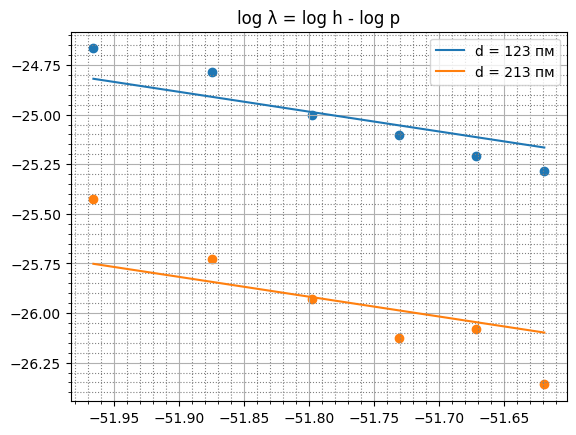

In [3]:
# прямая имеет вид y = bx + a
def coefficients(X, Y):
    x_middle = np.sum(X) / len(X)
    y_middle = np.sum(Y) / len(Y)
    b = 0 # числитель
    s = 0 # знаменатель
    for k in range(len(X)):
        b += (X[k] - x_middle) * (Y[k] - y_middle)
        s += (X[k] - x_middle)**2
    b /= s
    a = y_middle - x_middle*b
    return b, a

x1 = log_p
y1 = log_l1

b, a = coefficients(x1, y1)
print(b, a)
a = -76.78501901998489
b = -1
x = np.linspace(min(x1), max(x1))
y = a + b*x
plt.plot(x, y, label = "d = 123 пм")
plt.scatter(x1, y1)
print(np.exp(a))

y2 = log_l2
b, a = coefficients(x1, y2)
print(b, a)
a = -77.7178024634448
b = -1
y = a + b*x
plt.plot(x, y, label = "d = 213 пм")
plt.scatter(x1, y2)
print(np.exp(a))

plt.minorticks_on()
plt.grid(True, which='both')
plt.grid(which='minor', color='gray', linestyle=':')
plt.title("log λ = log h - log p")
plt.legend()

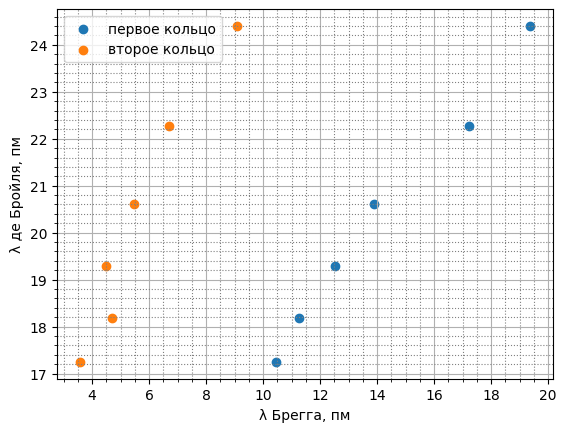

In [6]:
plt.scatter(l1*10**(12), ll, label = "первое кольцо")

plt.scatter(l2*10**(12), ll, label = "второе кольцо")
# plt.scatter(x1, y2)

plt.minorticks_on()
plt.grid(True, which='both')
plt.grid(which='minor', color='gray', linestyle=':')
plt.xlabel("λ Брегга, пм")
plt.ylabel("λ де Бройля, пм")
plt.legend()